# 🌟 Exercise 1: Duplicate Detection and Removal

### Instructions

**Objective**: Identify and remove duplicate entries in the Titanic dataset.

- Load the Titanic dataset.
- Identify if there are any duplicate rows based on all columns.
- Remove any duplicate rows found in the dataset.
- Verify the removal of duplicates by checking the number of rows before and after the duplicate removal.

*Hint*: Use the duplicated() and drop_duplicates() functions in Pandas.

## Answer

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# Load the titanic dataset
titanic_raw_df = pd.read_csv("data/train.csv")

In [3]:
# first look at the data
titanic_raw_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# shape - how big is the data?
titanic_raw_df.shape

(891, 12)

In [5]:
# info() - what data types? what's missing?
titanic_raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
# describe() - statistics for numeric columns
titanic_raw_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
# === STEP 1: CHECK FOR DUPLICATES ===
# Create working copy
df = titanic_raw_df.copy()

# Count duplicates: df.duplicated().sum()
print(f"There are {df.duplicated().sum()} duplicate rows in the dataset.")

There are 0 duplicate rows in the dataset.


**Since there are no duplicate rows, there is no need to drop rows from the dataset.**

# 🌟 Exercise 2: Handling Missing Values

### Instructions

- Identify columns in the Titanic dataset with missing values.
- Explore different strategies for handling missing data, such as removal, imputation, and filling with a constant value.
- Apply each strategy to different columns based on the nature of the data.

*Hint*: Review methods like `dropna()`, `fillna()`, and `SimpleImputer` from `scikit-learn`.

## Answer

In [8]:
# Count missing values for each column
missing_counts = df.isnull().sum()

# Count the percentage of missing values for each column
missing_pct = (missing_counts / len(df)) * 100

# Create dataframe with mising count and missing percentage columns
missing_df = pd.DataFrame(
    {
        'Missing Count': missing_counts,
        'Missing %': missing_pct
    }
)

# Print only columns with non-zero missing count
missing_df[missing_df['Missing Count'] > 0]



,Missing Count,Missing %
Age,177,19.865320
Cabin,687,77.104377
Embarked,2,0.224467


In [9]:
# Since more than 50% of the data is missing for Cabin, we drop the corresponding column

print(f"Number of columns BEFORE dropping: {len(df.columns)}")
df = df.drop(columns=['Cabin'])
print(f"Number of columns AFTER dropping: {len(df.columns)}")

Number of columns BEFORE dropping: 12
Number of columns AFTER dropping: 11


In [10]:
# Since the percentage of Age values missing is less than 50%, we impute a value
# We first check whether there the data for Age could be skewed

skew_value = df['Age'].skew()
print(f"Skewness: {skew_value}")

# Since the distribution is approximately symmetrical, we use the mean for imputation

print(f"Age values missing before: {df['Age'].isnull().sum()}")
age_imputer = SimpleImputer(strategy='mean')
df['Age'] = age_imputer.fit_transform(df[['Age']])

print(f"Mean age used: {age_imputer.statistics_[0]}")
print(f"Age missing after: {df['Age'].isnull().sum()}")


Skewness: 0.38910778230082704
Age values missing before: 177
Mean age used: 29.69911764705882
Age missing after: 0


In [11]:
# Since the percentage of Embark values missing is less than 50%, we impute a value
# Since the Embark data is categorical, we use the mode

print(f"Embarked missing before: {df['Embarked'].isnull().sum()}")

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

print(f"Embarked missing after: {df['Embarked'].isnull().sum()}")

Embarked missing before: 2
Embarked missing after: 0


In [12]:
# Check remaining missing values

df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

# 🌟 Exercise 3: Feature Engineering

### Instructions

- Create new features, such as Family Size from SibSp and Parch, and Title extracted from the Name column.
- Convert categorical variables into numerical form using techniques like one-hot encoding or label encoding.
- You will encode new categorical features (like Title) here, but do not scale numerical features yet — that will come after outlier handling.

*Hint*: Utilize Pandas for data manipulation and scikit-learn’s preprocessing module for encoding.

## Answer

In [13]:
# Look at family columns: sibsp (siblings/spouses) and parch (parents/children)
df[['SibSp', 'Parch']].head(10)

,SibSp,Parch
0,1,0
1,1,0
2,0,0
3,1,0
4,0,0
5,0,0
6,0,0
7,3,1
8,0,2
9,1,0


In [14]:
# family_size = sibsp + parch + 1 (include the passenger)

df['family_size'] = df['SibSp'] + df['Parch'] + 1

# Check the distribution
df['family_size'].value_counts().sort_index()

family_size
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7
Name: count, dtype: int64

In [15]:
# Pattern: "Lastname, Title. Firstname"
df['Name'].head(10)

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str

In [16]:
# Check value_counts() of extracted titles

df['title'] = df['Name'].str.extract(r',\s*([^.]+)\.')

df['title'].value_counts()

title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [17]:
# === SIMPLIFY TITLES ===
# Create mapping: common titles stay, rare ones become 'Rare'
# Mlle → Miss, Mme → Mrs

title_mapping = {
    'Mr': 'Mr',
    'Miss': 'Miss',
    'Mrs': 'Mrs',
    'Master': 'Master',
    # map rare/foreign titles
    'Dr': 'Rare',
    'Rev': 'Rare',
    'Col': 'Rare',
    'Mlle': 'Miss',
    'Major': 'Rare',
    'Ms': 'Mrs',
    'Mme': 'Mrs',
    'Don': 'Rare',
    'Lady': 'Rare',
    'Sir': 'Rare',
    'Capt': 'Rare',
    'the Countess': 'Rare',
    'Jonkheer': 'Rare'
}

df['title'] = df['title'].map(title_mapping)
df['title'].value_counts()

title
Mr        517
Miss      184
Mrs       127
Master     40
Rare       23
Name: count, dtype: int64

# 🌟 Exercise 4: Outlier Detection and Handling

**Goal**: Detect and cap or transform outliers in columns like Fare and Age.

1. Visualize distributions using boxplots or histograms to identify potential outliers.
2. Use IQR or Z-score methods to detect them.
3. Handle outliers with:

  - Quantile capping (e.g. 0.98)
  - Log transformation
  - Row removal

4. Compare the dataset before and after treatment.

📌  *Note*: Small differences between 0.98 and 0.99 quantiles are normal when extreme values are rare or far apart. Use `df.quantile()` to explore and choose thresholds empirically, backed by visualization.



## Answer

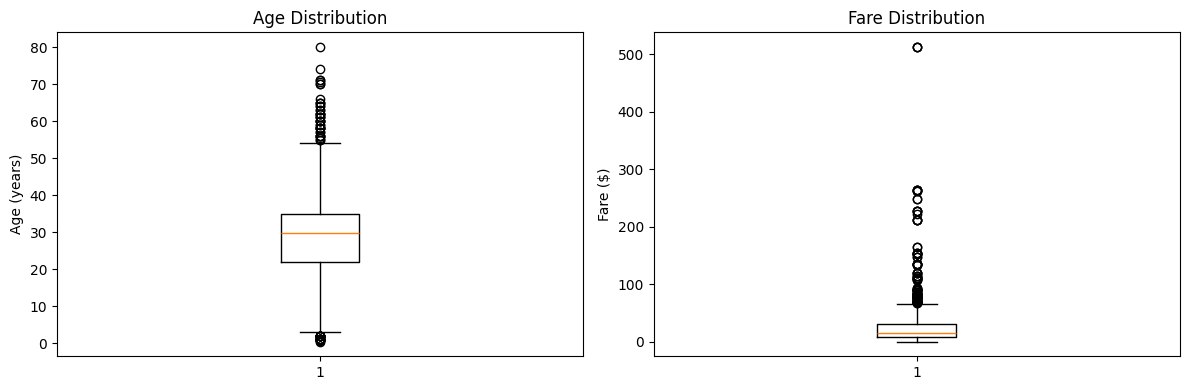


Boxplot interpretation:
  Box = middle 50% of data (Q1 to Q3)
  Line in box = median
  Whiskers = 1.5 × IQR from box
  Dots outside whiskers = OUTLIERS


In [18]:
# Visualize distributions with boxplots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Age'])
axes[0].set_title('Age Distribution')
axes[0].set_ylabel('Age (years)')

axes[1].boxplot(df['Fare'].dropna())
axes[1].set_title('Fare Distribution')
axes[1].set_ylabel('Fare ($)')

plt.tight_layout()
plt.show()

print("\nBoxplot interpretation:")
print("  Box = middle 50% of data (Q1 to Q3)")
print("  Line in box = median")
print("  Whiskers = 1.5 × IQR from box")
print("  Dots outside whiskers = OUTLIERS")

In [19]:
# === CALCULATE IQR FOR FARE ===
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1

# Calculate upper/lower bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): ${Q1}")
print(f"Q3 (75th percentile): ${Q3}")
print(f"IQR: ${IQR}")

print(f"Lower bound: ${lower_bound}")
print(f"Upper bound: ${upper_bound}")

outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f"Outliers detected: {len(outliers)/len(df) * 100:.1f}% of data")

Q1 (25th percentile): $7.9104
Q3 (75th percentile): $31.0
IQR: $23.0896
Lower bound: $-26.724
Upper bound: $65.6344
Outliers detected: 13.0% of data


In [20]:
# === CAP OUTLIERS AT 98TH PERCENTILE ===
fare_cap = df['Fare'].quantile(0.98)
outliers_count = (df['Fare'] > fare_cap).sum()

print(f"Capping fare at 98th percentile: ${fare_cap}")
print(f"Values to be capped: {outliers_count}")
print("Before capping")
print(f"Max fare: ${df['Fare'].max()}")

df['Fare'] = df['Fare'].clip(upper=fare_cap)
# Show before/after max values
print("After capping")
print(f"Max fare: ${df['Fare'].max()}")

Capping fare at 98th percentile: $211.3375
Values to be capped: 17
Before capping
Max fare: $512.3292
After capping
Max fare: $211.3375


In [21]:
# === CALCULATE IQR FOR AGE ===
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
# Calculate upper/lower bounds
# Count outliers

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1 (25th percentile): {Q1} years")
print(f"Q3 (75th percentile): {Q3} years")
print(f"IQR: {IQR} years")

print(f"Lower bound: {lower_bound} years")
print(f"Upper bound: {upper_bound} years")

outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentege of outliers: {len(outliers)/len(df) * 100:.1f}% of data")

Q1 (25th percentile): 22.0 years
Q3 (75th percentile): 35.0 years
IQR: 13.0 years
Lower bound: 2.5 years
Upper bound: 54.5 years
Number of outliers: 66
Percentege of outliers: 7.4% of data


In [22]:
# Log transformation: inadequate for this dataset, since skewness is very small
# Row removal: inadequate for this dataset, because the dataset is already too small
# The best option: cap dataset using 1st lower/ 98th upper (since there are lower bound outliers as well)

# Calculate the lower and upper quantile limits (1st/98th percentiles)
lower_limit = df['Age'].quantile(q=0.01)
upper_limit = df['Age'].quantile(q=0.98)

print(f"Lower limit for Age capping (1st percentile): {lower_limit}")
print(f"Upper limit for Age capping (98th percentile): {upper_limit}")

# 3. Verify the changes
print("\nOriginal Age statistics:")
print(df['Age'].describe())

df['Age'] = df['Age'].clip(lower=lower_limit, upper=upper_limit)

print("\nCapped Age statistics (using .clip()):")
print(df['Age'].describe())

# Note that the standard deviation is now lower.
# The number of outliers remain the same though.

Lower limit for Age capping (1st percentile): 1.0
Upper limit for Age capping (98th percentile): 62.0

Original Age statistics:
count    891.000000
mean      29.699118
std       13.002015
min        0.420000
25%       22.000000
50%       29.699118
75%       35.000000
max       80.000000
Name: Age, dtype: float64

Capped Age statistics (using .clip()):
count    891.000000
mean      29.598478
std       12.699979
min        1.000000
25%       22.000000
50%       29.699118
75%       35.000000
max       62.000000
Name: Age, dtype: float64


# 🌟 Exercise 6: Feature Encoding

**Goal**: Finalize categorical variable encoding.

1. Identify remaining categorical columns (e.g. Sex, Embarked, Title).
2. Apply:
    - One-Hot Encoding for nominal variables.
    - Label Encoding if any ordinal variables remain.
3. Merge encoded columns back into the main dataset.

📌 *Reminder* : Encoding comes after handling missing values and outliers, but before scaling (if applicable).

## Answer

In [23]:
# === IDENTIFY CATEGORICAL COLUMNS ===
# What categorical columns do we need to encode?
# sex, embarked, title

print(f"sex: {df['Sex'].unique()}")
print(f"embarked: {df['Embarked'].unique()}")
print(f"title: {df['title'].unique()}")


sex: <StringArray>
['male', 'female']
Length: 2, dtype: str
embarked: <StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str
title: <StringArray>
['Mr', 'Mrs', 'Miss', 'Master', 'Rare']
Length: 5, dtype: str


In [24]:
# === LABEL ENCODE SEX ===
sex_mapping = {'male': 0, 'female': 1}

df['sex_encoded'] = df['Sex'].map(sex_mapping)

print(df[['Sex', 'sex_encoded']].head())

df = df.drop(columns=['Sex'])


      Sex  sex_encoded
0    male            0
1  female            1
2  female            1
3  female            1
4    male            0


In [25]:
# === ONE-HOT ENCODE EMBARKED ===

embarked_dummies = pd.get_dummies(df['Embarked'], prefix='Embarked', drop_first=True).astype(int)
embarked_dummies.head()

,Embarked_Q,Embarked_S
0,0,1
1,0,0
2,0,1
3,0,1
4,0,1


In [26]:
# Add one-hot columns to our dataframe

df = pd.concat([df, embarked_dummies], axis=1)
# Drop 'Embark' because it is redundant (it's the same as Embark_Q = 0, Embark_S = 0)
df = df.drop('Embarked', axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,family_size,title,sex_encoded,Embarked_Q,Embarked_S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,Mr,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,Mrs,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,Miss,1,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,Mrs,1,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,Mr,0,0,1


In [27]:
# === ONE-HOT ENCODE TITLE ===
title_dummies = pd.get_dummies(df['title'], prefix='title').astype(int)
title_dummies.head()

,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare
0,0,0,1,0,0
1,0,0,0,1,0
2,0,1,0,0,0
3,0,0,0,1,0
4,0,0,1,0,0


In [28]:
# Add one-hot columns to our dataframe

df = pd.concat([df, title_dummies], axis=1)
# Drop 'title' because it is redundant
df = df.drop('title', axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,family_size,sex_encoded,Embarked_Q,Embarked_S,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,0,0,1,0,0,1,0,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,1,0,0,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,1,0,1,0,1,0,0,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,1,0,1,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,0,1,0,0,1,0,0


# 🌟 Exercise 7: Data Transformation for Age Feature

Goal: Create and encode age groups.

1. Use pd.cut() to create bins for life stages (e.g. child, teen, adult, senior).
2. Apply one-hot encoding using pd.get_dummies().

📌 *Example* : You might define bins like [0, 12, 18, 60, 100] and label them accordingly.

## Answer

In [29]:
# === CREATE AGE GROUPS ===
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)
df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,family_size,sex_encoded,Embarked_Q,Embarked_S,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare,age_group
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,0,0,1,0,0,1,0,0,Adult
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,1,0,0,0,0,0,1,0,Adult
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,1,0,1,0,1,0,0,0,Adult
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,1,0,1,0,0,0,1,0,Adult
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,0,0,1,0,0,1,0,0,Adult


In [30]:
# === ONE-HOT ENCODE AGE GROUP ===
age_group_dummies = pd.get_dummies(df['age_group'], prefix='age_group').astype(int)
age_group_dummies.head()

,age_group_Child,age_group_Teen,age_group_Adult,age_group_Senior
0,0,0,1,0
1,0,0,1,0
2,0,0,1,0
3,0,0,1,0
4,0,0,1,0


In [31]:
# Add one-hot columns to our dataframe

df = pd.concat([df, age_group_dummies], axis=1)
# Drop 'age_group' because it is redundant
df = df.drop('age_group', axis=1)

df.head()

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,family_size,...,Embarked_S,title_Master,title_Miss,title_Mr,title_Mrs,title_Rare,age_group_Child,age_group_Teen,age_group_Adult,age_group_Senior
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,2,...,1,0,0,1,0,0,0,0,1,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,2,...,0,0,0,0,1,0,0,0,1,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,1,...,1,0,1,0,0,0,0,0,1,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,2,...,1,0,0,0,1,0,0,0,1,0
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,1,...,1,0,0,1,0,0,0,0,1,0


# 🌟 Exercise 5: Data Standardization and Normalization

**Goal**: Scale numerical features to prepare for modeling.

1. Use StandardScaler (mean = 0, std = 1) for normally distributed features.
2. Use MinMaxScaler (range [0, 1]) for features that are skewed or bounded.

📌 **Important**: Perform this step after outlier treatment to avoid distortion caused by extreme values.

## Answer

In [32]:
SKEW_THRESHOLD = 0.5

# Select numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# ============ SKEWNESS SERIES =================
# Calculate skewness for numeric columns
# The result is a Series where the index is the column name and the value is the skewness
skewness_series = numeric_cols.skew()
# ==============================================

# ============ NOT SKEWED DATASET ==============
# Filter columns based on the skewness threshold
# This creates a boolean mask where True means "not skewed"
not_skewed_mask = abs(skewness_series) <= SKEW_THRESHOLD

# Get the names of the columns that meet the condition
not_skewed_columns = skewness_series[not_skewed_mask].index.tolist()

# Select not skewed columns from dataframe
not_skewed_df = df[not_skewed_columns]

print("\nNot skewed columns before normalization via StandardScaler:\n")
print(not_skewed_df.head())

# Initialize and fit the StandardScaler
scaler = StandardScaler()
scaled_not_skewed = scaler.fit_transform(not_skewed_df)

# Create dataframe with transformed data
not_skewed_scaled_df = pd.DataFrame(scaled_not_skewed, columns=not_skewed_columns, index=df.index)

print("\nNot skewed columns after normalization via StandardScaler:\n")
print(not_skewed_scaled_df.head())

print()
print("="*80)
print()

# ================== SKEWED DATASET ==================
# Filter columns based on the skewness threshold
# This creates a boolean mask where True means "skewed"
skewed_mask = abs(skewness_series) > SKEW_THRESHOLD

# Get the names of the columns that meet the condition
skewed_columns = skewness_series[skewed_mask].index.tolist()

# Select not skewed columns from dataframe
skewed_df = df[skewed_columns]

print("Skewed columns before normalization via MinMaxScaler:\n")
print(skewed_df.head())

# Initialize and fit the MinMaxScaler
mm_scaler = MinMaxScaler()
scaled_skewed = mm_scaler.fit_transform(skewed_df)

# Create dataframe with transformed data
skewed_scaled_df = pd.DataFrame(scaled_skewed, columns=skewed_columns, index=df.index)

print("\nSkewed columns after normalization via MinMaxScaler:\n")
print(skewed_scaled_df.head())

# ================ INTEGRATE NORMALIZED DATASET TO DATAFRANE ================

df[not_skewed_columns] = not_skewed_scaled_df
df[skewed_columns] = skewed_scaled_df



Not skewed columns before normalization via StandardScaler:

   PassengerId  Survived   Age  title_Mr
0            1         0  22.0         1
1            2         1  38.0         0
2            3         1  26.0         0
3            4         1  35.0         0
4            5         0  35.0         1

Not skewed columns after normalization via StandardScaler:

   PassengerId  Survived       Age  title_Mr
0    -1.730108 -0.789272 -0.598642  0.850532
1    -1.726220  1.266990  0.661910 -1.175735
2    -1.722332  1.266990 -0.283504 -1.175735
3    -1.718444  1.266990  0.425556 -1.175735
4    -1.714556 -0.789272  0.425556  0.850532


Skewed columns before normalization via MinMaxScaler:

   Pclass  SibSp  Parch     Fare  family_size  sex_encoded  Embarked_Q  \
0       3      1      0   7.2500            2            0           0   
1       1      1      0  71.2833            2            1           0   
2       3      0      0   7.9250            1            1           0   
3       